In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import yaml

import os
import pickle as pkl
import numpy as np

from src.utils.results_class import ResultsBuffer
from src.plotting_fns import get_bounds, correct_xgb_preds
from src.bayesian_opt import ValidationObj
from src.xgboost import XgboostModel
import matplotlib.pyplot as plt


# from optuna.visualization.matplotlib import plot_optimization_history
# from optuna.visualization.matplotlib import plot_parallel_coordinate
# from optuna.visualization.matplotlib import plot_param_importances, plot_slice

# plot_optimization_history(study)
# plt.show()

# plot_parallel_coordinate(study)
# plt.show()
# plot_param_importances(study)
# plot_optimization_history(study)
# plot_slice(study)
# plt.show()

c:\Users\bbritoschiele\Documents\PHD_files\2026\adaptive_bayesian_filter_prognostics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Color setup and some utilitary functions for plotting

In [8]:
# Color and label size setup

# Color hex codes
color_baseline = '#9caed0'
color_base_1 = '#8467a3'
color_base_2 = '#737ab4'
color_base_3 = '#658bbe'
color_base_4 = '#5e9bc2'
color_base_5 = '#9bd1db'
accent_1 = '#21688c'

# Font sizes
x_font_size_standard = 13
y_font_size_standard = 13

plt.style.use(os.path.join('src', 'presentation.mplstyle'))

In [3]:
def get_predictions(study_mse, study_crps,xgb_model:XgboostModel , fold, config):
    validation_mse = ValidationObj(config,study_mse.best_params,fold)
    validation_crps = ValidationObj(config,study_crps.best_params,fold)
    
    _, _,_,results_mse = validation_mse()
    gt_x, gt_param,rul_gt,results_crps = validation_crps()
    preds, y_series = xgb_model.eval(fold)
    
    
    
    return gt_x, gt_param, rul_gt, results_mse, results_crps, preds


In [ ]:

def plot_id_rul_all(id, gt_rul,results_mse, results_crps,results_xgb, alpha = 0.05):
    
    rul_pred_mse, lb_mse, ub_mse = get_bounds(results_mse[id].get_prognostic(), results_mse[id].get_w(), alpha=alpha)
    rul_pred_crps, lb_crps, ub_crps = get_bounds(results_crps[id].get_prognostic(), results_crps[id].get_w(), alpha=alpha)
    results_xgb = correct_xgb_preds(results_xgb[id], len(rul_pred_crps))
    
    x = np.arange(len(rul_pred_mse))
    plt.figure(figsize=(20,10))
    plt.plot(gt_rul[id], color = accent_1, label = 'GT')
    plt.plot(results_xgb, color = color_base_3, label = 'XGBoost', alpha = 0.5)
    plt.plot(x, rul_pred_mse, color = color_base_4, label = 'Adaptive PF+MSE')
    plt.fill_between(x, lb_mse, ub_mse,color = color_base_4 , alpha = 0.2)
    plt.plot(x, rul_pred_crps, color = color_base_1, label = 'Adaptive PF+CRPS')
    plt.fill_between(x, lb_crps, ub_crps,color = color_base_1 , alpha = 0.2)
    plt.xlabel('Time [cycles]')
    plt.ylabel('RUL [cycles]')
    plt.legend()
    plt.show()

def plot_id_rul_XGB(id, gt_rul,results_mse, results_crps,results_xgb, alpha = 0.05):
    
    rul_pred_mse, lb_mse, ub_mse = get_bounds(results_mse[id].get_prognostic(), results_mse[id].get_w(), alpha=alpha)
    rul_pred_crps, lb_crps, ub_crps = get_bounds(results_crps[id].get_prognostic(), results_crps[id].get_w(), alpha=alpha)
    results_xgb = correct_xgb_preds(results_xgb[id], len(rul_pred_crps))
    
    x = np.arange(len(rul_pred_mse))
    plt.figure(figsize=(20,10))
    plt.plot(gt_rul[id], color = accent_1, label = 'GT')
    plt.plot(results_xgb, color = color_base_3, label = 'XGBoost', alpha = 0.5)
    plt.plot(x, rul_pred_mse, color = color_base_4, label = 'Adaptive PF+MSE')
    plt.fill_between(x, lb_mse, ub_mse,color = color_base_4 , alpha = 0.2)
    plt.plot(x, rul_pred_crps, color = color_base_1, label = 'Adaptive PF+CRPS')
    plt.fill_between(x, lb_crps, ub_crps,color = color_base_1 , alpha = 0.2)
    plt.xlabel('Time [cycles]')
    plt.ylabel('RUL [cycles]')
    plt.legend()
    plt.show()


## Open the different sets of predictions

In [5]:
path = os.path.join('results', 'test_crps_long2.pkl')
with open(path, 'rb') as f:
    result = pkl.load(f )
config_crps, study_crps = result


path = os.path.join('results', 'test_mse_long2.pkl')
with open(path, 'rb') as f:
    result = pkl.load(f )
config_mse, study_mse = result

with open(os.path.join("src", "sweep_config.yml"), "rb") as f:
    config = yaml.safe_load(f)
xgb_model = XgboostModel(config)
xgb_model.load('xgb')

In [12]:

gt_x, gt_param, rul_gt, results_mse, results_crps, results_xgb = get_predictions(study_mse, study_crps,xgb_model, 'special',config)

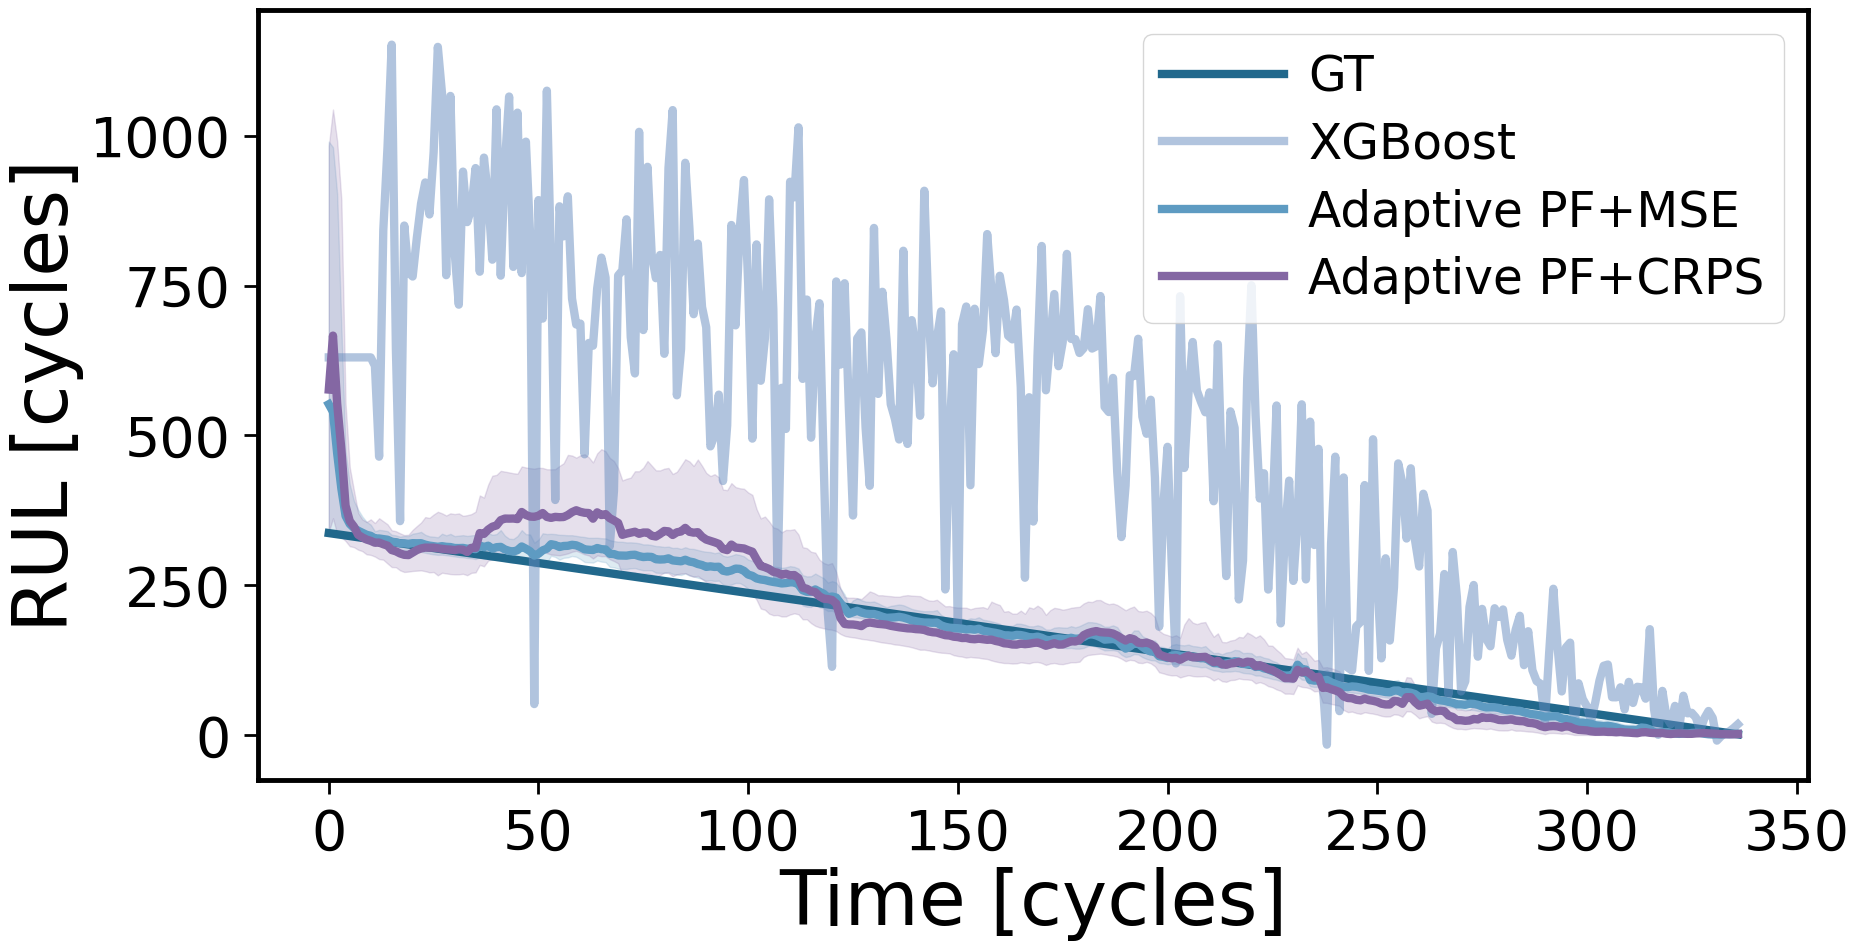

In [13]:


plot_id_rul_all(0, rul_gt, results_mse, results_crps, results_xgb)


In [ ]:
best_params = study.best_params
print(config["dataloader_config"])
validation = src.ValidationObj(config,best_params,'special')
gt_x, gt_param,rul_gt,results = validation()
# print(compute_loss(gt_x, gt_param,rul_gt,results ))

# src.plot_hi(gt_x,results)

# src.plot_param(gt_param, results)
src.plot_rul(rul_gt, results)
plt.show()

print(best_params)

In [ ]:
with open(os.path.join("src", "sweep_config.yml"), "rb") as f:
    config = yaml.safe_load(f)
xgb_model = XgboostModel(config)
xgb_model.load('xgb')

In [ ]:
preds, y_series = xgb_model.eval('special')

for p,y in zip(preds, y_series):
    plt.figure()
    plt.plot(p, color = 'b')
    plt.plot(y, color = 'r')
    plt.show()
    